# Experiment 0.1 — Frozen full-Relative10 Linear on growing prefixes

**Question:** if gesture start is known but the endpoint is unknown, how early can the existing complete-gesture `Relative10 + Linear` solution become useful when Relative10 is recomputed over the currently observed prefix?

This notebook is **analysis-only**. Run the Slurm pipeline first; this notebook reads finalized artifacts and frozen model files, aggregates the five user-disjoint splits, and plots the growing-prefix behavior. It does not fit or retrain any classifier.

Protocol: complete gestures train the scaler and Linear model. At 10, 20, 30, ... observed samples, the entire current prefix is repartitioned into ten relative bins and passed through that frozen scaler and frozen Linear model.

In [5]:
from __future__ import annotations

import sys
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


# ---------------------------------------------------------------------
# Locate repository root BEFORE importing from scripts
# ---------------------------------------------------------------------
HERE = Path.cwd().resolve()

if (HERE / "scripts").is_dir():
    REPO_ROOT = HERE
elif (HERE.parent / "scripts").is_dir():
    REPO_ROOT = HERE.parent
else:
    raise RuntimeError(f"Cannot find repository root from {HERE}")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))


# ---------------------------------------------------------------------
# Repository imports
# ---------------------------------------------------------------------
from scripts import experiment_0_1_growing_prefix_relative10 as exp01
from scripts import experiment_3_2_nonlinear_temporal_interaction as exp32


# ---------------------------------------------------------------------
# Artifact paths
# ---------------------------------------------------------------------
ARTIFACT_DIR = exp01.results_dir(REPO_ROOT)

paths = {
    "results": ARTIFACT_DIR / "experiment_0_1_results.csv",
    "prefix_curves": ARTIFACT_DIR / "experiment_0_1_prefix_curves.csv",
    "summary": ARTIFACT_DIR / "experiment_0_1_summary.csv",
    "prefix_summary": ARTIFACT_DIR / "experiment_0_1_prefix_summary.csv",
    "baseline_parity": ARTIFACT_DIR / "experiment_0_1_baseline_parity.csv",
    "provenance": ARTIFACT_DIR / "provenance.json",
}

missing = [str(path) for path in paths.values() if not path.exists()]

if missing:
    raise FileNotFoundError(
        "Run/finalize Experiment 0.1 first. Missing:\n"
        + "\n".join(missing)
    )


# ---------------------------------------------------------------------
# Load finalized results
# ---------------------------------------------------------------------
results = pd.read_csv(paths["results"])
curves = pd.read_csv(paths["prefix_curves"])
summary = pd.read_csv(paths["summary"])
prefix_summary = pd.read_csv(paths["prefix_summary"])
parity = pd.read_csv(paths["baseline_parity"])

provenance = json.loads(
    paths["provenance"].read_text(encoding="utf-8")
)


# ---------------------------------------------------------------------
# Sanity output
# ---------------------------------------------------------------------
print("Repository:", REPO_ROOT)
print("Artifacts:", ARTIFACT_DIR)
print("Split seeds:", provenance["split_seeds"])
print(
    "Prefix cadence:",
    f"{provenance['prefix_step_samples']} samples = "
    f"{provenance['prefix_step_ms']:.2f} ms",
)

Repository: /home/zhaolongwei_umass_edu/projects/writingRing
Artifacts: /home/zhaolongwei_umass_edu/projects/writingRing/notebooks/artifacts/experiment_0_1_growing_prefix_relative10/frozen_full_linear_v1
Split seeds: [11, 23, 37, 53, 71]
Prefix cadence: 10 samples = 156.25 ms


## 1. Protocol sanity and baseline parity

The complete-gesture result must reproduce the saved Experiment 1.3.3 `relative_10bin + linear` result split-by-split. This verifies that Experiment 0.1 changed only the evaluation protocol, not the user split, representation, scaler, or Linear baseline.

In [6]:
display(pd.Series(provenance, name='value').to_frame())
display(parity.round(8))
print('Maximum absolute baseline drift:', parity['abs_difference'].max())
assert parity['abs_difference'].max() <= exp01.BASELINE_PARITY_TOL

,value
curve_semantics,active gestures only; n_samples and coverage a...
evaluation,"At every 10 observed samples, recompute Relati..."
event_channel_count,30
expected_runs,5
experiment_id,experiment_0_1_growing_prefix_relative10
future_data,No sample after the current prefix is used to ...
prefix_step_ms,156.25
prefix_step_samples,10
protocol_version,frozen_full_linear_v1
relative_bins,10


,split_seed,exp01_test_ba,reference_test_ba,difference,abs_difference
0,11,0.817824,0.817824,0.0,0.0
1,23,0.683647,0.683647,0.0,0.0
2,37,0.728622,0.728622,0.0,0.0
3,53,0.605478,0.605478,0.0,0.0
4,71,0.738127,0.738127,0.0,0.0


Maximum absolute baseline drift: 0.0


## 2. Complete-gesture Relative10 reference

These are the five frozen full-gesture Linear baselines. Balanced Accuracy is the primary metric.

In [7]:
full_cols = [
    'split_seed',
    'val_balanced_accuracy',
    'test_balanced_accuracy',
    'test_accuracy',
    'test_macro_f1',
]
display(results[full_cols].round(4))
display(summary.round(4))
FULL_TEST_BA_MEAN = float(results['test_balanced_accuracy'].mean())
FULL_TEST_BA_SD = float(results['test_balanced_accuracy'].std(ddof=1))
print(f'Full Relative10 test BA: {FULL_TEST_BA_MEAN:.4f} ± {FULL_TEST_BA_SD:.4f}')

,split_seed,val_balanced_accuracy,test_balanced_accuracy,test_accuracy,test_macro_f1
0,11,0.5299,0.8178,0.8173,0.8151
1,23,0.6866,0.6836,0.6949,0.7003
2,37,0.7499,0.7286,0.7215,0.7223
3,53,0.7748,0.6055,0.6286,0.6067
4,71,0.8394,0.7381,0.7444,0.7376


,metric,mean,std
0,test_balanced_accuracy,0.7147,0.0779
1,test_accuracy,0.7214,0.0690
2,test_macro_f1,0.7164,0.0750


Full Relative10 test BA: 0.7147 ± 0.0779


## 3. Growing-prefix test trajectory

Each point uses only gestures that have at least that many observed samples. Therefore the late part of the raw curve has lower coverage and a changing active cohort. The matched-control section below corrects for that selection effect.

split_seed,11,23,37,53,71
observed_time_ms,,,,,
156.25,0.0816,0.0991,0.0854,0.1008,0.0845
312.50,0.1044,0.0850,0.0842,0.1008,0.0668
468.75,0.0999,0.0987,0.0958,0.0997,0.0694
625.00,0.0604,0.0529,0.0957,0.0472,0.0469
781.25,0.0963,0.0774,0.0768,0.0757,0.0717
937.50,0.1208,0.0712,0.1404,0.0583,0.0729
1093.75,0.1858,0.2461,0.2598,0.0907,0.2046
1250.00,0.2163,0.3162,0.2961,0.1779,0.3363
1406.25,0.4963,0.2965,0.2264,0.2768,0.5511


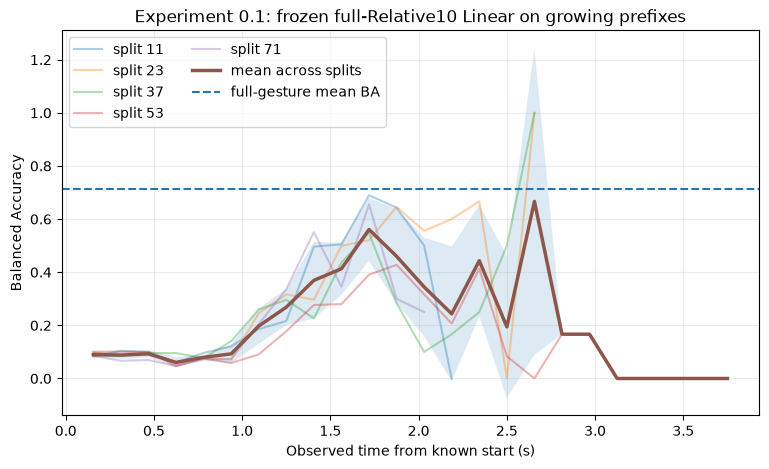

In [8]:
test_curves = curves[curves['cohort'] == 'test'].copy()
test_curves['observed_time_s'] = test_curves['observed_time_ms'] / 1000.0

ba_pivot = test_curves.pivot(
    index='observed_time_ms', columns='split_seed', values='balanced_accuracy'
).sort_index()
display(ba_pivot.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
for split_seed, group in test_curves.groupby('split_seed'):
    group = group.sort_values('observed_time_s')
    ax.plot(group['observed_time_s'], group['balanced_accuracy'], alpha=0.35, label=f'split {split_seed}')
mean_curve = test_curves.groupby('observed_time_s', as_index=False).agg(
    mean_ba=('balanced_accuracy', 'mean'),
    sd_ba=('balanced_accuracy', 'std'),
)
ax.plot(mean_curve['observed_time_s'], mean_curve['mean_ba'], linewidth=2.5, label='mean across splits')
ax.fill_between(
    mean_curve['observed_time_s'],
    mean_curve['mean_ba'] - mean_curve['sd_ba'].fillna(0.0),
    mean_curve['mean_ba'] + mean_curve['sd_ba'].fillna(0.0),
    alpha=0.15,
)
ax.axhline(FULL_TEST_BA_MEAN, linestyle='--', linewidth=1.5, label='full-gesture mean BA')
ax.set_xlabel('Observed time from known start (s)')
ax.set_ylabel('Balanced Accuracy')
ax.set_title('Experiment 0.1: frozen full-Relative10 Linear on growing prefixes')
ax.grid(alpha=0.25)
ax.legend(ncol=2)
plt.show()

## 4. Matched active-cohort full-gesture control

At later ticks, only longer gestures remain active. Comparing prefix BA with the overall full-gesture BA can therefore be misleading. Here the notebook loads each frozen model and computes full-gesture predictions on **the exact same active test gestures** used at each prefix tick. No fitting occurs.

The primary diagnostic becomes:

`prefix BA - matched full-gesture BA`

A gap near zero means the current prefix retains nearly all classification performance available from the complete gesture for that same cohort.

In [9]:
cohort = exp32.load_cohort(REPO_ROOT)
matched_rows = []

for split_seed in exp01.SPLIT_SEEDS:
    parts = exp32.make_user_split(cohort.manifest, split_seed)
    test_frame = parts['test'].reset_index(drop=True)
    full_x, full_y = exp01.full_relative10_features(cohort, test_frame)

    model_path = ARTIFACT_DIR / 'models' / f'split{split_seed}.npz'
    if not model_path.exists():
        raise FileNotFoundError(f'Missing frozen model: {model_path}')
    frozen = np.load(model_path)
    z = exp01.apply_scaler(full_x, frozen['scaler_mean'], frozen['scaler_std'])
    scores = z @ frozen['coef'].T + frozen['intercept'][None, :]
    full_pred = frozen['classes'][np.argmax(scores, axis=1)]
    lengths = np.minimum(
        test_frame['valid_length'].to_numpy(dtype=np.int64), exp01.GLOBAL_PADDED_LENGTH
    )

    split_curve = test_curves[test_curves['split_seed'] == split_seed].sort_values('observed_samples')
    for row in split_curve.itertuples(index=False):
        active = lengths >= int(row.observed_samples)
        matched_metrics = exp32._classification_metrics(full_y[active], full_pred[active])
        matched_rows.append({
            'split_seed': split_seed,
            'observed_samples': int(row.observed_samples),
            'observed_time_ms': float(row.observed_time_ms),
            'observed_time_s': float(row.observed_time_ms) / 1000.0,
            'coverage': float(row.coverage),
            'n_samples': int(row.n_samples),
            'prefix_balanced_accuracy': float(row.balanced_accuracy),
            'matched_full_balanced_accuracy': float(matched_metrics['balanced_accuracy']),
            'prefix_minus_matched_full_balanced_accuracy': float(
                row.balanced_accuracy - matched_metrics['balanced_accuracy']
            ),
        })

matched = pd.DataFrame(matched_rows)
matched_summary = matched.groupby(['observed_samples', 'observed_time_ms', 'observed_time_s'], as_index=False).agg(
    mean_prefix_ba=('prefix_balanced_accuracy', 'mean'),
    sd_prefix_ba=('prefix_balanced_accuracy', 'std'),
    mean_matched_full_ba=('matched_full_balanced_accuracy', 'mean'),
    sd_matched_full_ba=('matched_full_balanced_accuracy', 'std'),
    mean_prefix_minus_full_ba=('prefix_minus_matched_full_balanced_accuracy', 'mean'),
    sd_prefix_minus_full_ba=('prefix_minus_matched_full_balanced_accuracy', 'std'),
    mean_coverage=('coverage', 'mean'),
    mean_n_samples=('n_samples', 'mean'),
)
display(matched_summary.round(4))

/home/zhaolongwei_umass_edu/.conda/envs/writingring-gpu/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/zhaolongwei_umass_edu/.conda/envs/writingring-gpu/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/zhaolongwei_umass_edu/.conda/envs/writingring-gpu/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/zhaolongwei_umass_edu/.conda/envs/writingring-gpu/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/zhaolongwei_umass_edu/.conda/envs/writingring-gpu/lib/pyth

,observed_samples,observed_time_ms,observed_time_s,mean_prefix_ba,sd_prefix_ba,mean_matched_full_ba,sd_matched_full_ba,mean_prefix_minus_full_ba,sd_prefix_minus_full_ba,mean_coverage,mean_n_samples
0,10,156.25,0.1562,0.0903,0.0090,0.7147,0.0779,-0.6245,0.0861,1.0000,172.6000
1,20,312.50,0.3125,0.0882,0.0151,0.7147,0.0779,-0.6265,0.0798,1.0000,172.6000
2,30,468.75,0.4688,0.0927,0.0131,0.7147,0.0779,-0.6221,0.0812,1.0000,172.6000
3,40,625.00,0.6250,0.0606,0.0204,0.7147,0.0779,-0.6541,0.0745,1.0000,172.6000
4,50,781.25,0.7812,0.0796,0.0096,0.7169,0.0766,-0.6374,0.0707,0.9789,168.8000
5,60,937.50,0.9375,0.0927,0.0357,0.7127,0.0716,-0.6200,0.0579,0.9014,155.4000
6,70,1093.75,1.0938,0.1974,0.0668,0.7186,0.0795,-0.5212,0.0672,0.8057,138.6000
7,80,1250.00,1.2500,0.2685,0.0681,0.6490,0.0905,-0.3804,0.1184,0.6804,116.8000
8,90,1406.25,1.4062,0.3694,0.1445,0.6389,0.0918,-0.2695,0.1556,0.5265,90.0000
9,100,1562.50,1.5625,0.4131,0.0984,0.6131,0.1710,-0.2000,0.1203,0.3501,58.8000


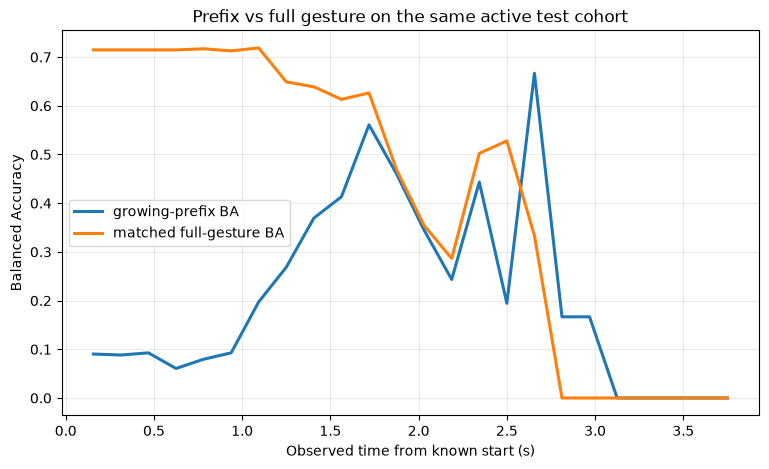

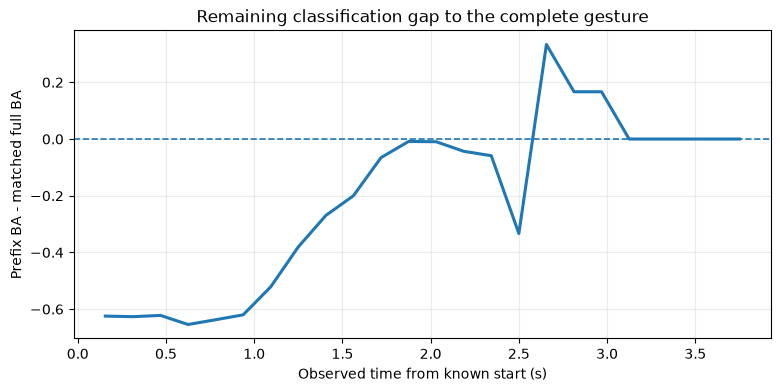

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(matched_summary['observed_time_s'], matched_summary['mean_prefix_ba'], linewidth=2.2, label='growing-prefix BA')
ax.plot(matched_summary['observed_time_s'], matched_summary['mean_matched_full_ba'], linewidth=2.2, label='matched full-gesture BA')
ax.set_xlabel('Observed time from known start (s)')
ax.set_ylabel('Balanced Accuracy')
ax.set_title('Prefix vs full gesture on the same active test cohort')
ax.grid(alpha=0.25)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(
    matched_summary['observed_time_s'],
    matched_summary['mean_prefix_minus_full_ba'],
    linewidth=2.2,
)
ax.axhline(0.0, linestyle='--', linewidth=1.2)
ax.set_xlabel('Observed time from known start (s)')
ax.set_ylabel('Prefix BA - matched full BA')
ax.set_title('Remaining classification gap to the complete gesture')
ax.grid(alpha=0.25)
plt.show()

## 5. Accuracy, macro-F1, and coverage

Balanced Accuracy is primary, but the other classification metrics should move consistently. Coverage must be read alongside all late-prefix results.

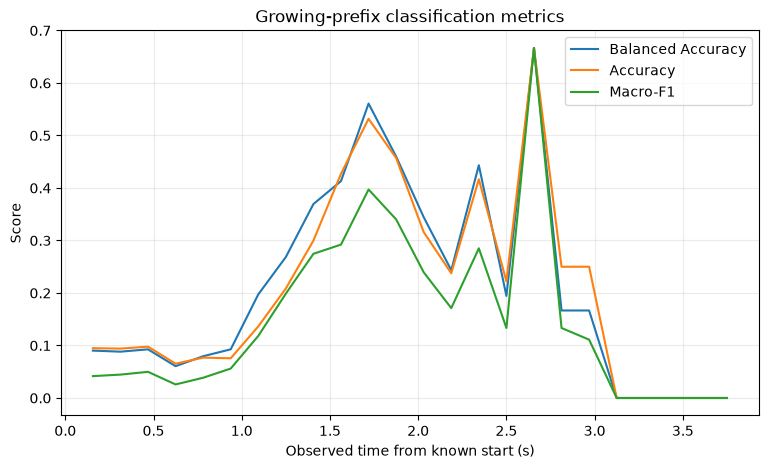

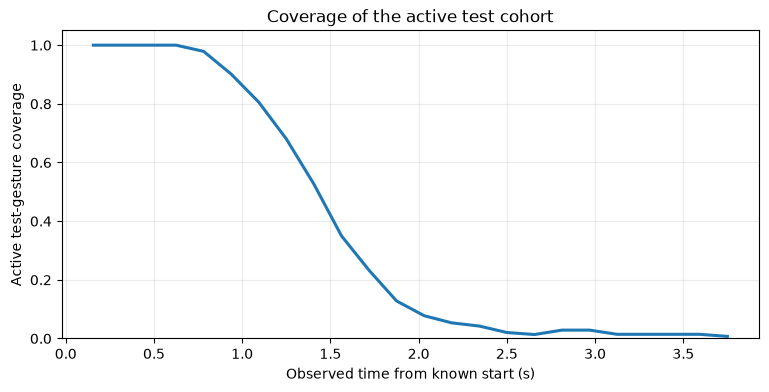

In [11]:
test_summary = prefix_summary[prefix_summary['cohort'] == 'test'].copy()
test_summary['observed_time_s'] = test_summary['observed_time_ms'] / 1000.0

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(test_summary['observed_time_s'], test_summary['mean_balanced_accuracy'], label='Balanced Accuracy')
ax.plot(test_summary['observed_time_s'], test_summary['mean_accuracy'], label='Accuracy')
ax.plot(test_summary['observed_time_s'], test_summary['mean_macro_f1'], label='Macro-F1')
ax.set_xlabel('Observed time from known start (s)')
ax.set_ylabel('Score')
ax.set_title('Growing-prefix classification metrics')
ax.grid(alpha=0.25)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(test_summary['observed_time_s'], test_summary['mean_coverage'], linewidth=2.2)
ax.set_xlabel('Observed time from known start (s)')
ax.set_ylabel('Active test-gesture coverage')
ax.set_ylim(0.0, 1.05)
ax.set_title('Coverage of the active test cohort')
ax.grid(alpha=0.25)
plt.show()

## 6. Decision-oriented summary

The table below samples the trajectory near 0.5, 1.0, 1.5, and 2.0 seconds. Use the matched full-gesture gap together with coverage when deciding whether exact endpoint detection is necessary.

In [12]:
targets_s = [0.5, 1.0, 1.5, 2.0]
selected = []
for target in targets_s:
    index = (matched_summary['observed_time_s'] - target).abs().idxmin()
    row = matched_summary.loc[index].copy()
    row['target_time_s'] = target
    selected.append(row)
decision_table = pd.DataFrame(selected)[[
    'target_time_s',
    'observed_samples',
    'observed_time_s',
    'mean_prefix_ba',
    'mean_matched_full_ba',
    'mean_prefix_minus_full_ba',
    'mean_coverage',
    'mean_n_samples',
]]
display(decision_table.round(4))

high_coverage = matched_summary[matched_summary['mean_coverage'] >= 0.80].copy()
for tolerance in (0.05, 0.02, 0.01):
    eligible = high_coverage[high_coverage['mean_prefix_minus_full_ba'] >= -tolerance]
    if len(eligible):
        first = eligible.sort_values('observed_time_s').iloc[0]
        print(
            f'Within {tolerance:.0%} BA of matched full performance at >=80% coverage: '
            f"{first['observed_time_s']:.3f} s ({int(first['observed_samples'])} samples)"
        )
    else:
        print(f'Never within {tolerance:.0%} BA of matched full performance while coverage >=80%.')

,target_time_s,observed_samples,observed_time_s,mean_prefix_ba,mean_matched_full_ba,mean_prefix_minus_full_ba,mean_coverage,mean_n_samples
2,0.5,30.0,0.4688,0.0927,0.7147,-0.6221,1.0000,172.6
5,1.0,60.0,0.9375,0.0927,0.7127,-0.6200,0.9014,155.4
9,1.5,100.0,1.5625,0.4131,0.6131,-0.2000,0.3501,58.8
12,2.0,130.0,2.0312,0.3444,0.3540,-0.0096,0.0777,12.0


Never within 5% BA of matched full performance while coverage >=80%.
Never within 2% BA of matched full performance while coverage >=80%.
Never within 1% BA of matched full performance while coverage >=80%.


## Interpretation

- If the growing-prefix gap approaches zero **well before the reference endpoint and while coverage remains high**, exact end detection is probably not necessary for classification. A coarse confidence/stability commit rule may be sufficient.
- If the gap stays large until near full duration, the last portion of the gesture carries important discriminative information and endpoint handling remains important.
- If the raw prefix BA rises at late times but the matched full-gesture BA rises similarly, that apparent improvement is mostly active-cohort selection rather than genuine prefix convergence.
- This experiment deliberately freezes a classifier trained only on complete gestures. Poor prefix performance therefore measures distribution shift; it does **not** prove that a prefix-aware classifier cannot work.
- The experiment assumes the gesture start is known. It does not solve the harder start-unknown, end-unknown continuous-stream problem.